In [80]:
# https://youtu.be/tepxdcepTbY
"""
@author: Sreenivas Bhattiprolu

Code tested on Tensorflow: 2.2.0
    Keras: 2.4.3

dataset: https://finance.yahoo.com/quote/GE/history/
Also try S&P: https://finance.yahoo.com/quote/%5EGSPC/history?p=%5EGSPC
"""

import os

os.environ["KERAS_BACKEND"] = "torch"

import numpy as np
from keras.models import Sequential
from keras.layers import LSTM
from keras.layers import Dense, Dropout
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
from pathlib import Path
import seaborn as sns
from natsort import natsorted
from math import floor, log10
from sklearn.model_selection import train_test_split

In [127]:

#from datetime import datetime
trainX = []
trainY = []

t1 = 'xcentre'
t2 = 'ycentre'

T_list = [t2]
target_num = 1

n_future = 1  # Number of days we want to look into the future based on the past days.
n_past = 2

N = n_future + n_past

#Read the csv file
for i, cell in enumerate(natsorted((Path(r'C:\Users\2MY\Documents\Uni Work\Level 4\TR-Y4-Project\LSTM_Prac\ML_Data').iterdir()))):
    if i < 100 :
        redex = [t2]
        df = pd.read_csv(cell)
        #print(cell)  #7 columns, including the Date.
         
        if df.shape[0] > N:
            print(cell)
#Separate dates for future plotting
#train_times = pd.to_datetime(df['time']).dt.time
#print(train_times.tail(15))  #Check last few dates.
            w = 0
            for j, feature in enumerate(list(df)[1:]):
                if feature != t2:
                    redex.append(feature)
                    w +=1
                else:
                    continue
                    

            
            df = df.reindex(
                columns=redex)
            #Variables for training
            
            
            # df.columns = list(np.arange(0,w+1)) # use to test batching loop
            
            cols = list(df)
            
            #Date and volume columns are not used in training.
            # print(cols)  #['Open', 'High', 'Low', 'Close', 'Adj Close']
            #New dataframe with only training data - 5 columns
            
            df_for_training = np.array(df[cols].astype(float).round(decimals=2))
            
            
            # df_for_plot=df_for_training.tail(5000)
            # df_for_plot.plot.line()
            
            #LSTM uses sigmoid and tanh that are sensitive to magnitude so values need to be normalized
            # normalize the dataset
            
            scaler = StandardScaler()
            scaler = scaler.fit(df_for_training)
            df_for_training_scaled = scaler.transform(df_for_training)
            
            #print(df_for_training_scaled)
            
            #As required for LSTM networks, we require to reshape an input data into n_samples x timesteps x n_features.
            #In this example, the n_features is 5. We will make timesteps = 14 (past days data used for training).
            
            #Empty lists to be populated using formatted training data
            
            
  # Number of past days we want to use to predict the future.
            
            #Reformat input data into a shape: (n_samples x timesteps x n_features)
            #In my example, my df_for_training_scaled has a shape (12823, 5)
            #12823 refers to the number of data points and 5 refers to the columns (multi-variables).
            for i in range(n_past, len(df_for_training_scaled) - n_future):
                trainX.append(df_for_training_scaled[i - n_past:i, 0])
                trainY.append(df_for_training_scaled[i + n_future - 1:i + n_future, 0]) #encodes number of targets in Y dataset
                        
        else:
            continue
   
   
#print(df_for_training_scaled)        
# trainX, trainY = np.array(trainX), np.array(trainY)
X_train, X_test, y_train, y_test = train_test_split(trainX, trainY, test_size =1, random_state=10)
X_train, X_test, y_train, y_test = np.array(X_train), np.array(X_test), np.array(y_train), np.array(y_test)


print('X_train shape == {}.'.format(X_train.shape))
print('y_train shape == {}.'.format(y_train.shape))

print('X_test shape == {}.'.format(X_test.shape))
print('y_test shape == {}.'.format(y_test.shape))

#In my case, trainX has a shape (12809, 14, 5).
        #12809 because we are looking back 14 days (12823 - 14 = 12809).
        #Remember that we cannot look back 14 days until we get to the 15th day.
        #Also, trainY has a shape (12809, 1). Our model only predicts a single value, but
        #it needs multiple variables (5 in my example) to make this prediction.
        #This is why we can only predict a single day after our training, the day after where our data ends.
        #To predict more days in future, we need all the 5 variables which we do not have.
        #We need to predict all variables if we want to do that.

C:\Users\2MY\Documents\Uni Work\Level 4\TR-Y4-Project\LSTM_Prac\ML_Data\cell_1.csv
C:\Users\2MY\Documents\Uni Work\Level 4\TR-Y4-Project\LSTM_Prac\ML_Data\cell_2.csv
C:\Users\2MY\Documents\Uni Work\Level 4\TR-Y4-Project\LSTM_Prac\ML_Data\cell_3.csv
C:\Users\2MY\Documents\Uni Work\Level 4\TR-Y4-Project\LSTM_Prac\ML_Data\cell_4.csv
C:\Users\2MY\Documents\Uni Work\Level 4\TR-Y4-Project\LSTM_Prac\ML_Data\cell_5.csv
C:\Users\2MY\Documents\Uni Work\Level 4\TR-Y4-Project\LSTM_Prac\ML_Data\cell_6.csv
C:\Users\2MY\Documents\Uni Work\Level 4\TR-Y4-Project\LSTM_Prac\ML_Data\cell_7.csv
C:\Users\2MY\Documents\Uni Work\Level 4\TR-Y4-Project\LSTM_Prac\ML_Data\cell_8.csv
C:\Users\2MY\Documents\Uni Work\Level 4\TR-Y4-Project\LSTM_Prac\ML_Data\cell_10.csv
C:\Users\2MY\Documents\Uni Work\Level 4\TR-Y4-Project\LSTM_Prac\ML_Data\cell_11.csv
C:\Users\2MY\Documents\Uni Work\Level 4\TR-Y4-Project\LSTM_Prac\ML_Data\cell_12.csv
C:\Users\2MY\Documents\Uni Work\Level 4\TR-Y4-Project\LSTM_Prac\ML_Data\cell_13.csv


In [128]:
X_test[0]

array([0.79392081, 1.15875411])

In [129]:
y_test[0]

array([1.61071178])

In [149]:
# define the Autoencoder model

model = Sequential()
model.add(LSTM(150, activation='relu', return_sequences=True, input_shape=(X_train.shape[1], target_num)))
model.add(LSTM(64, activation='relu'))
model.add(Dense(64))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')
model.summary()

# fit the model

C:\Users\2MY\anaconda3\envs\Research\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_24 (LSTM)                  │ (None, 2, 150)         │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_25 (LSTM)                  │ (None, 64)             │        55,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 150,465 (587.75 KB)

 Trainable params: 150,465 (587.75 KB)

 Non-trainable params: 0 (0.00 B)

In [133]:
model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


array([[1.2505693]], dtype=float32)

In [151]:
prediction_copies = np.hstack((np.vstack((model.predict(X_test), y_test)), np.zeros((2,df_for_training_scaled.shape[1] - y_test.shape[1]))))
Test = scaler.inverse_transform(prediction_copies)[:, 0]
print(((Test[1]-Test[0])/Test[1])*100)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1.4849804395983404


In [150]:
acc_df = []
for i in range(10,11):
    history = model.fit(X_train, y_train, epochs=i, validation_split=0.2, verbose=1)
    prediction_copies = np.hstack((np.vstack(model.predict(X_test), y_test), np.zeros((y_test.shape[1],df_for_training_scaled.shape[1] - y_test.shape[1] ))))
    
    acc_df.append(scaler.inverse_transform(prediction_copies)[:, 0:2])
    


Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.8741 - val_loss: 0.6345
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.4542 - val_loss: 0.4605
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.3380 - val_loss: 0.4021
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.3069 - val_loss: 0.3595
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2577 - val_loss: 0.3079
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2768 - val_loss: 0.3066
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2516 - val_loss: 0.3065
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.2080 - val_loss: 0.3014
Epoch 9/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.2216 - val_loss: 0.3128
Epoch 10/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1914 - val_loss: 0.3050
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


TypeError: vstack() takes 1 positional argument but 2 were given

In [135]:
acc_df

[array([[ 263.20966959, 3474.76890678]])]

In [383]:
prediction_copies = np.hstack((model.predict(X_test), y_test, np.zeros((y_test.shape[1],df_for_training_scaled.shape[1] - y_test.shape[1]*2 ))))
scaler.inverse_transform(prediction_copies)[:, 0:2]



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


array([[ 253.26888227, 2564.00317467]])

In [345]:
results = np.array(acc_df).reshape(len(acc_df), np.shape(acc_df)[2])
results = pd.DataFrame(np.c_[np.arange(1,len(acc_df) + 1),results], columns=['epoch', 'X_pred', 'y_pred', 'X_truth', 'y_truth'])
results

,epoch,X_pred,y_pred,X_truth,y_truth
0,1.0,903.120428,253.726113,2807.56768,5.196575
1,2.0,903.323899,253.759830,2807.56768,5.196575
2,3.0,903.366311,253.692566,2807.56768,5.196575
3,4.0,903.049700,253.670190,2807.56768,5.196575
4,5.0,903.177111,253.651269,2807.56768,5.196575
5,6.0,902.849576,253.557347,2807.56768,5.196575
6,7.0,902.760407,253.641307,2807.56768,5.196575
7,8.0,902.583238,253.671752,2807.56768,5.196575
8,9.0,903.200195,253.643168,2807.56768,5.196575
9,10.0,903.045071,253.652805,2807.56768,5.196575


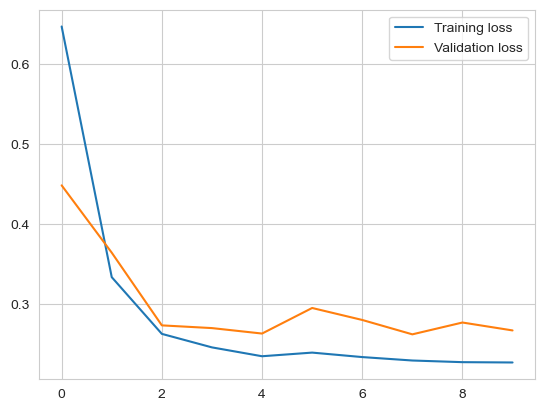

In [115]:
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.legend()